<a href="https://colab.research.google.com/github/jipsa1901-prog/MY-ASSIGNMENTS/blob/main/Copy_of_Python_DA_Assignment_2_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python DA Assignment 2: Data Visualization

## 1) Loading the Taxis Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (6433, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), 

## 2) Handling Missing Values

In [ ]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nColumns with missing data:", missing[missing > 0].index.tolist())

Missing values per column:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Columns with missing data: ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']


In [ ]:
# Numerical columns -> impute with the median
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# 'payment' is a general categorical column -> impute with the mode
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])

# Zone/borough columns are critical location data and cannot be reasonably
# guessed with a mode, so drop rows where they are missing
df = df.dropna(subset=["pickup_zone", "pickup_borough", "dropoff_zone", "dropoff_borough"])

print("Remaining missing values:", df.isnull().sum().sum())
print("Final shape:", df.shape)

Remaining missing values: 0
Final shape: (6383, 14)


## 3) Visualizations using Matplotlib / Pandas Plot

### Line Chart: fare over time

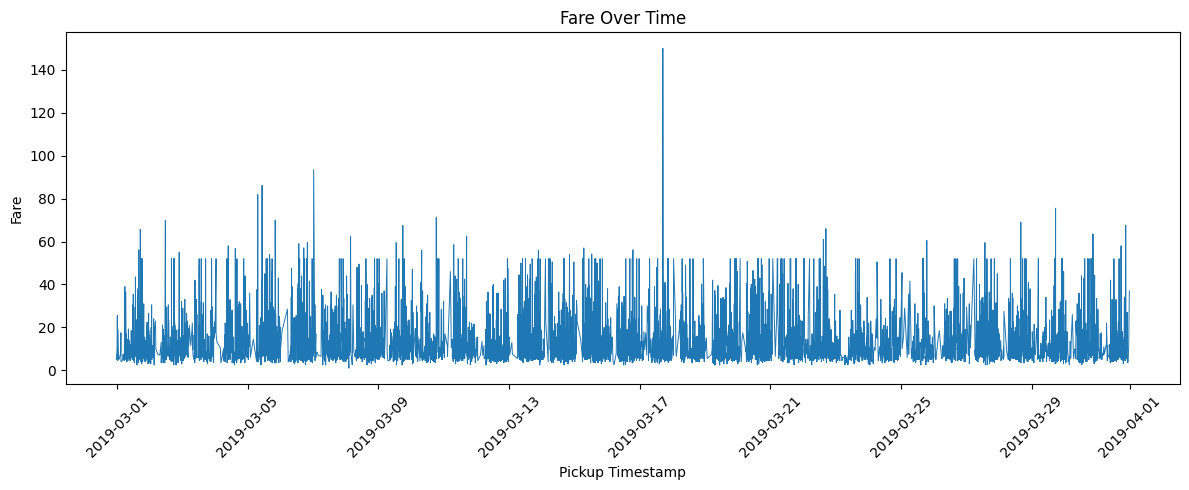

In [ ]:
df["pickup"] = pd.to_datetime(df["pickup"])
line_df = df.sort_values("pickup")

plt.figure(figsize=(12, 5))
plt.plot(line_df["pickup"], line_df["fare"], linewidth=0.7)
plt.title("Fare Over Time")
plt.xlabel("Pickup Timestamp")
plt.ylabel("Fare")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar Chart: total fare per pickup borough

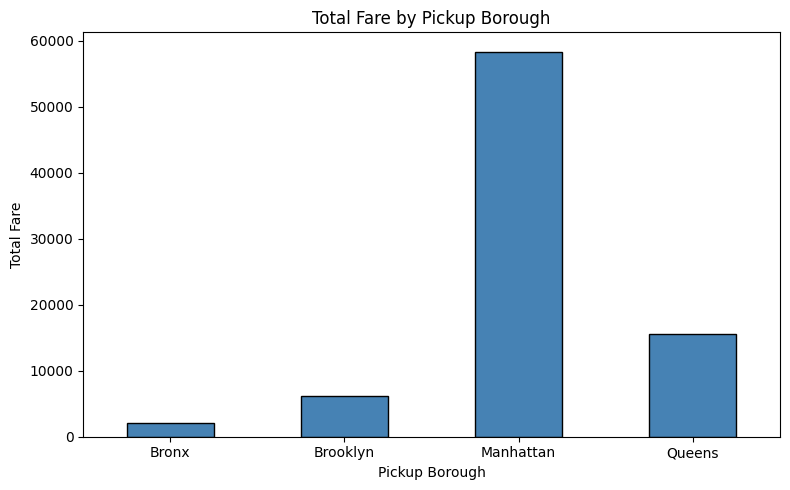

In [ ]:
borough_fare = df.groupby("pickup_borough")["fare"].sum()

borough_fare.plot(kind="bar", figsize=(8, 5), color="steelblue", edgecolor="black")
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Pie Chart: trips by payment method

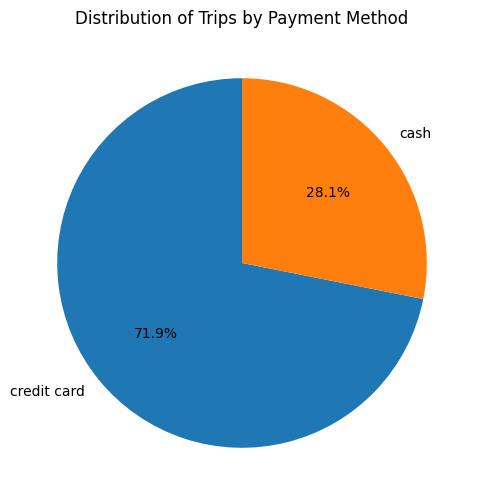

In [ ]:
payment_counts = df["payment"].value_counts()

payment_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6), startangle=90)
plt.title("Distribution of Trips by Payment Method")
plt.ylabel("")
plt.show()

### Histogram: distribution of distance

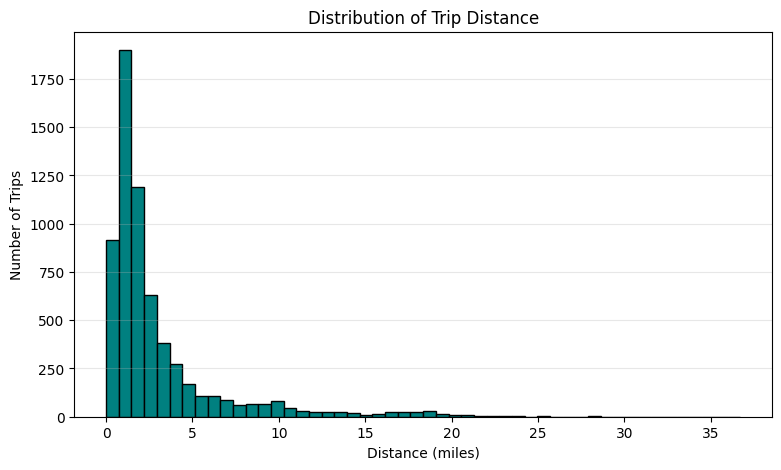

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df["distance"], bins=50, color="teal", edgecolor="black")
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Trips")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Box Plot: tip amount per pickup borough

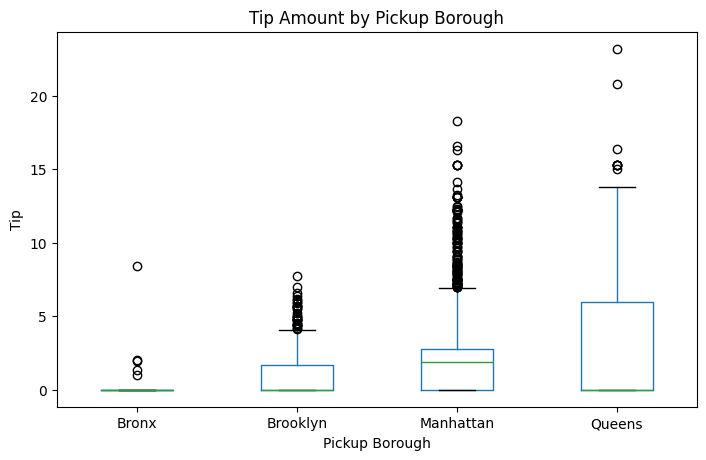

In [ ]:
df.boxplot(column="tip", by="pickup_borough", figsize=(8, 5), grid=False)
plt.title("Tip Amount by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip")
plt.show()

## Visualizations using Seaborn

### Count Plot: trips per pickup borough

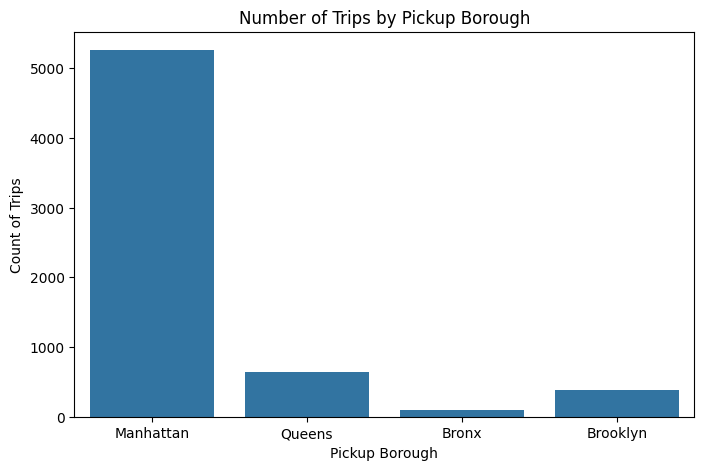

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pickup_borough")
plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Count of Trips")
plt.show()

### Scatter Plot: distance vs fare, coloured by pickup borough

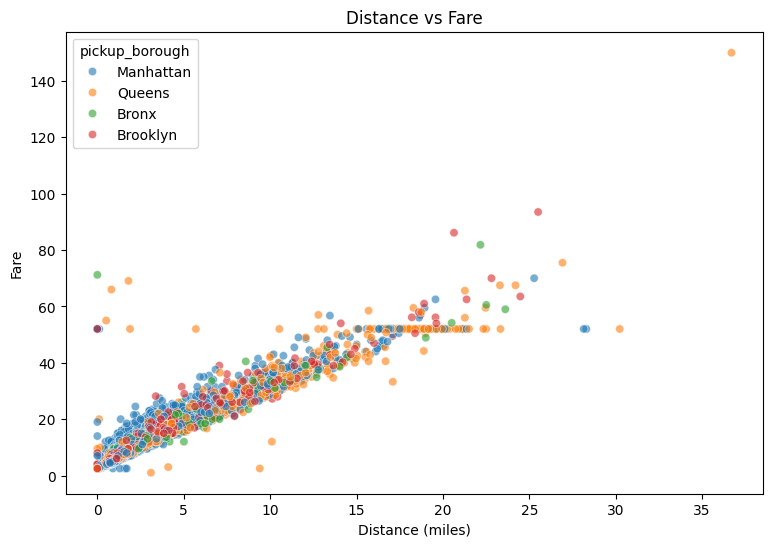

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="distance", y="fare", hue="pickup_borough", alpha=0.6)
plt.title("Distance vs Fare")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare")
plt.show()

### Heatmap: correlation matrix

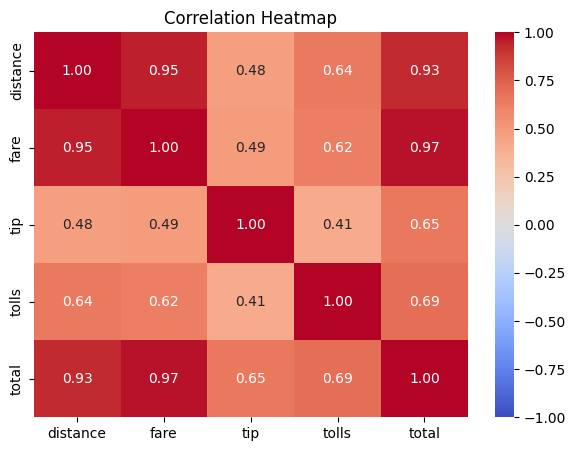

In [ ]:
corr = df[["distance", "fare", "tip", "tolls", "total"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

### Pair Plot: distance, fare, tip, total, coloured by pickup zone

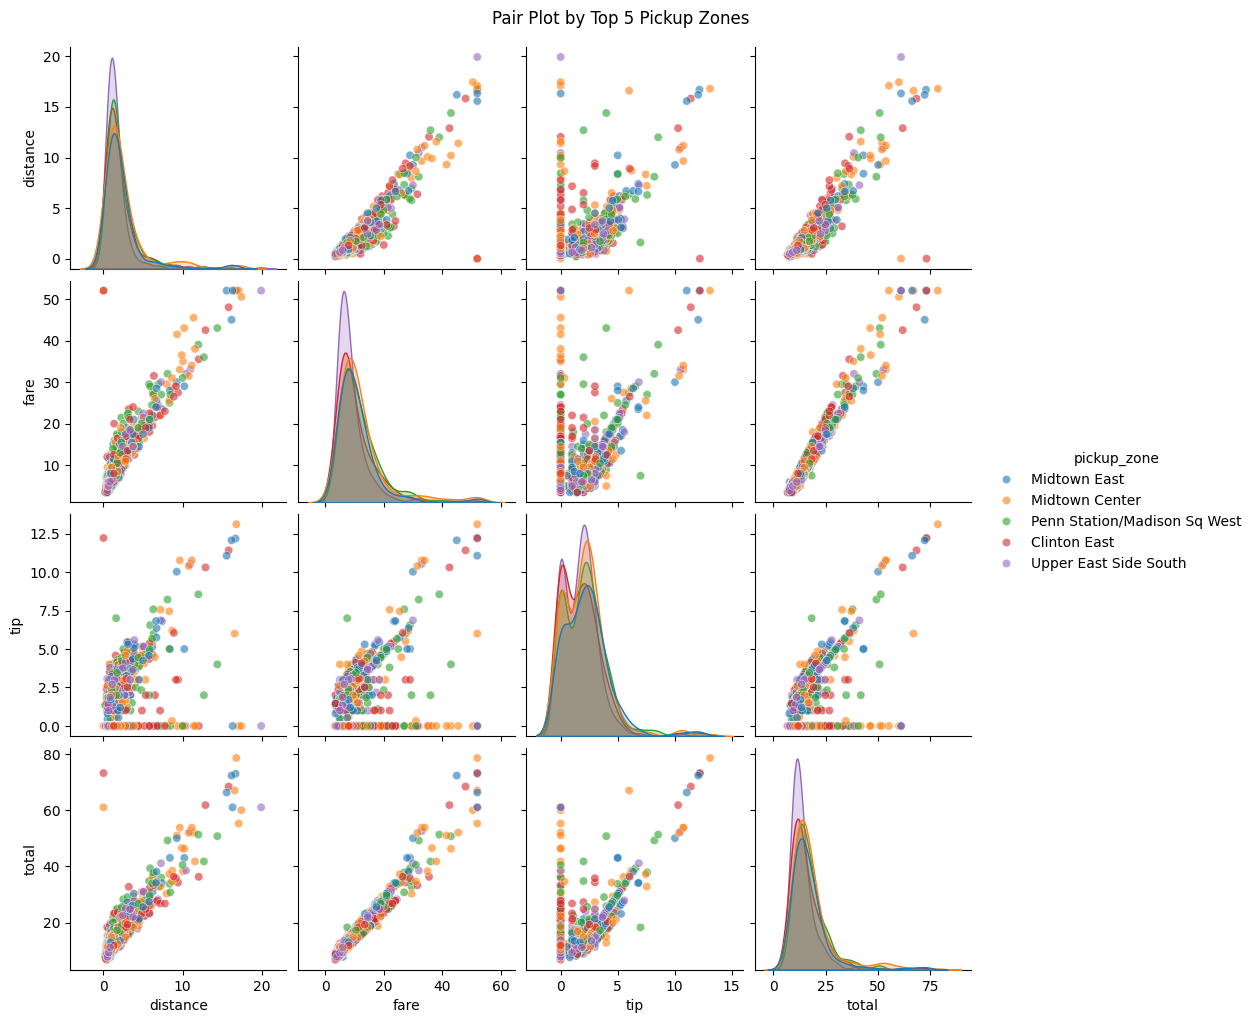

In [ ]:
# The dataset has ~190 pickup zones, which would make the plot unreadable.
# So only the 5 busiest pickup zones are used here.
top_zones = df["pickup_zone"].value_counts().head(5).index
pair_df = df[df["pickup_zone"].isin(top_zones)]

sns.pairplot(pair_df, vars=["distance", "fare", "tip", "total"],
             hue="pickup_zone", plot_kws={"alpha": 0.6})
plt.suptitle("Pair Plot by Top 5 Pickup Zones", y=1.02)
plt.show()

### Violin Plot: fare distribution per payment method

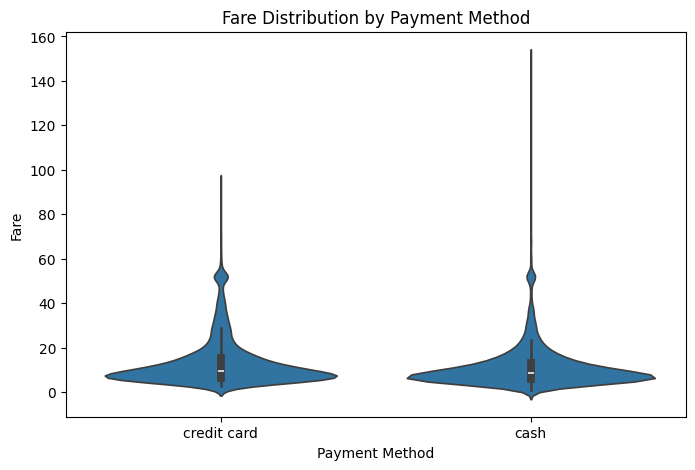

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="payment", y="fare")
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.show()